# Data Science — Pertemuan 10: Algoritma Klasifikasi

## Identitas Mahasiswa

**Nama:** Amin Siddik Rangkuti  
**NIM:** 220401010124  
**Kelas:** IF405  
**Program Studi:** PJJ Informatika  
**Mata Kuliah:** Data Science  
**Universitas:** Universitas Siber Asia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/main/Pertemuan_10_AminSiddikRangkuti_220401010124.ipynb)

## 1. Tujuan Praktikum

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu:

1. Memahami konsep **Ensemble Learning**.
2. Menjelaskan cara kerja **Random Forest**.
3. Membangun model klasifikasi untuk prediksi customer churn.
4. Mengevaluasi model menggunakan accuracy, precision, recall, F1-score, ROC-AUC, dan confusion matrix.
5. Menangani masalah **imbalanced dataset** menggunakan `class_weight="balanced"`.
6. Menampilkan **feature importance** untuk melihat fitur yang paling berpengaruh.

## 2. Import Library

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Library berhasil di-import")

Library berhasil di-import


## 3. Membuat Dataset Customer Churn

Dataset dibuat secara sintetis agar notebook dapat langsung dijalankan tanpa perlu file eksternal. Target `Churn` menunjukkan apakah pelanggan berhenti menggunakan layanan atau tidak.

In [17]:
np.random.seed(42)

n_samples = 600

tenure = np.random.randint(1, 73, n_samples)
monthly_charges = np.round(np.random.uniform(20, 120, n_samples), 2)
total_charges = np.round(tenure * monthly_charges + np.random.normal(0, 250, n_samples), 2)
total_charges = np.where(total_charges < 0, monthly_charges, total_charges)

contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.55, 0.25, 0.20])
internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.38, 0.45, 0.17])
payment_method = np.random.choice(
    ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
    n_samples, p=[0.40, 0.20, 0.20, 0.20]
)

# Membuat probabilitas churn berdasarkan pola umum
prob_churn = (
    0.10
    + (contract == 'Month-to-month') * 0.25
    + (internet_service == 'Fiber optic') * 0.12
    + (payment_method == 'Electronic check') * 0.10
    + (tenure < 12) * 0.18
    + (monthly_charges > 85) * 0.10
)
prob_churn = np.clip(prob_churn, 0, 0.85)

churn = np.random.binomial(1, prob_churn)

df = pd.DataFrame({
    'tenure': tenure,
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,
    'Contract': contract,
    'InternetService': internet_service,
    'PaymentMethod': payment_method,
    'Churn': churn
})

df.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,52,114.48,5082.76,Month-to-month,No,Electronic check,1
1,15,104.96,1356.84,One year,Fiber optic,Mailed check,0
2,72,44.73,3521.97,Two year,DSL,Electronic check,0
3,61,65.05,4053.83,Month-to-month,DSL,Mailed check,1
4,21,32.92,1022.29,Month-to-month,DSL,Credit card,0


## 4. Informasi Dataset

In [18]:
print("Jumlah baris dan kolom:", df.shape)
print("\nInformasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(df.isnull().sum())

Jumlah baris dan kolom: (600, 7)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           600 non-null    int64  
 1   MonthlyCharges   600 non-null    float64
 2   TotalCharges     600 non-null    float64
 3   Contract         600 non-null    object 
 4   InternetService  600 non-null    object 
 5   PaymentMethod    600 non-null    object 
 6   Churn            600 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 32.9+ KB

Jumlah nilai kosong:
tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
PaymentMethod      0
Churn              0
dtype: int64


## 5. Distribusi Target Churn

Pada kasus dunia nyata, data churn sering tidak seimbang. Oleh karena itu, distribusi kelas perlu dicek sebelum model dibuat.

Churn
0    370
1    230
Name: count, dtype: int64

Persentase target:
Churn
0    61.67
1    38.33
Name: count, dtype: float64


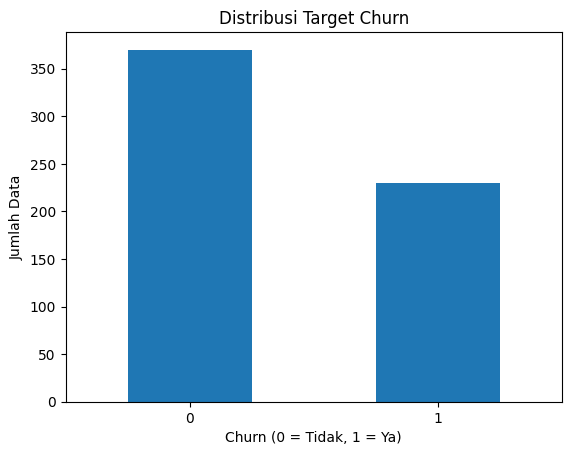

In [19]:
target_count = df['Churn'].value_counts().sort_index()
print(target_count)
print("\nPersentase target:")
print((target_count / len(df) * 100).round(2))

target_count.plot(kind='bar')
plt.title('Distribusi Target Churn')
plt.xlabel('Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

## 6. Memisahkan Fitur dan Target

In [20]:
X = df.drop('Churn', axis=1)
y = df['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['Contract', 'InternetService', 'PaymentMethod']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (480, 6)
Data test : (120, 6)


## 7. Preprocessing Data

Fitur numerik dinormalisasi menggunakan `StandardScaler`, sedangkan fitur kategorikal diubah menjadi bentuk numerik menggunakan `OneHotEncoder`.

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessor siap digunakan")

Preprocessor siap digunakan


## 8. Membuat Model Random Forest

Random Forest termasuk metode **bagging**, yaitu membangun banyak pohon keputusan secara paralel dan menggabungkan hasil prediksinya. Parameter `class_weight="balanced"` digunakan untuk membantu menangani data yang tidak seimbang.

In [22]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih")

Model Random Forest berhasil dilatih


## 9. Prediksi Model

In [23]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

result = X_test.copy()
result['Actual_Churn'] = y_test.values
result['Predicted_Churn'] = y_pred
result['Probability_Churn'] = np.round(y_proba, 3)

result.head(10)

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Actual_Churn,Predicted_Churn,Probability_Churn
210,48,109.96,5581.71,One year,DSL,Electronic check,1,0,0.133
98,37,73.21,2523.56,Month-to-month,Fiber optic,Mailed check,0,0,0.210
10,30,55.82,1907.85,Month-to-month,No,Electronic check,1,1,0.597
481,46,38.06,1671.60,Month-to-month,No,Bank transfer,0,1,0.710
446,17,97.09,1557.60,One year,Fiber optic,Electronic check,1,0,0.377
569,35,119.49,4248.62,Month-to-month,Fiber optic,Electronic check,0,1,0.573
179,69,54.89,3981.66,Month-to-month,DSL,Mailed check,0,0,0.320
420,2,58.31,325.70,One year,DSL,Mailed check,0,0,0.267
504,54,51.53,2853.84,Month-to-month,Fiber optic,Electronic check,0,0,0.327
311,45,28.53,1477.12,Month-to-month,No,Electronic check,0,1,0.630


## 10. Evaluasi Model

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

evaluation = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, roc_auc]
})

evaluation['Score'] = evaluation['Score'].round(4)
evaluation

,Metric,Score
0,Accuracy,0.6250
1,Precision,0.5135
2,Recall,0.4130
3,F1-Score,0.4578
4,ROC-AUC,0.6112


## 11. Classification Report

In [25]:
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

              precision    recall  f1-score   support

 Tidak Churn       0.67      0.76      0.71        74
       Churn       0.51      0.41      0.46        46

    accuracy                           0.62       120
   macro avg       0.59      0.58      0.59       120
weighted avg       0.61      0.62      0.62       120



## 12. Confusion Matrix

[[56 18]
 [27 19]]


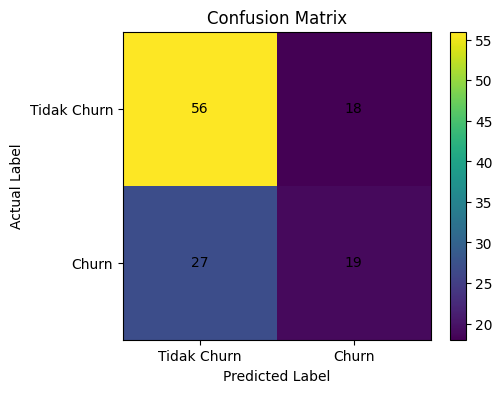

In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0, 1], ['Tidak Churn', 'Churn'])
plt.yticks([0, 1], ['Tidak Churn', 'Churn'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

### Interpretasi Metrik Customer Churn

Karena target churn cenderung tidak seimbang, **accuracy tidak boleh digunakan sendirian**. **Recall kelas Churn** penting untuk mengurangi pelanggan churn yang tidak terdeteksi (False Negative), sedangkan **F1-Score** membantu menilai keseimbangan antara recall dan precision. Confusion Matrix digunakan untuk melihat jumlah kesalahan prediksi pada masing-masing kelas secara langsung.

## 13. ROC Curve

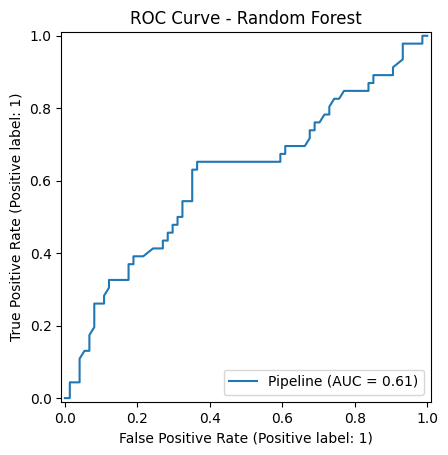

In [27]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('ROC Curve - Random Forest')
plt.show()

## 14. Feature Importance

Feature importance digunakan untuk melihat fitur mana yang paling berpengaruh dalam prediksi churn.

In [28]:
trained_preprocessor = rf_model.named_steps['preprocessor']
trained_classifier = rf_model.named_steps['classifier']

cat_names = trained_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': trained_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
2,TotalCharges,0.251491
0,tenure,0.251102
1,MonthlyCharges,0.239823
3,Contract_Month-to-month,0.048126
11,PaymentMethod_Electronic check,0.029912
12,PaymentMethod_Mailed check,0.026437
4,Contract_One year,0.025196
6,InternetService_DSL,0.024504
7,InternetService_Fiber optic,0.023116
9,PaymentMethod_Bank transfer,0.022864


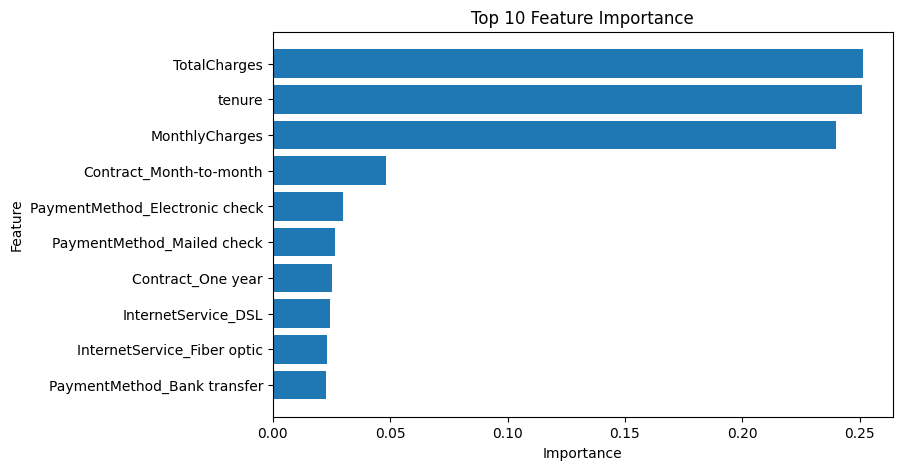

In [29]:
top_features = importance_df.head(10).sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 15. Prediksi Data Pelanggan Baru

In [30]:
new_customer = pd.DataFrame({
    'tenure': [5],
    'MonthlyCharges': [95.0],
    'TotalCharges': [475.0],
    'Contract': ['Month-to-month'],
    'InternetService': ['Fiber optic'],
    'PaymentMethod': ['Electronic check']
})

pred_label = rf_model.predict(new_customer)[0]
pred_proba = rf_model.predict_proba(new_customer)[:, 1][0]

print("Prediksi Churn:", "Ya" if pred_label == 1 else "Tidak")
print("Probabilitas Churn:", round(pred_proba, 3))

Prediksi Churn: Ya
Probabilitas Churn: 0.837


## Kesimpulan

Pada Pertemuan 10, saya mempelajari **Ensemble Learning** melalui **Random Forest** untuk prediksi **Customer Churn**, termasuk preprocessing data kategorikal/numerik, evaluasi model, feature importance, dan penanganan **imbalanced dataset** menggunakan `class_weight='balanced'`.

Temuan utama praktikum adalah bahwa **accuracy saja dapat menyesatkan pada data churn yang tidak seimbang**. Untuk kasus churn, **recall dan F1-Score kelas Churn** lebih relevan karena model perlu mampu menemukan pelanggan yang benar-benar berpotensi churn tanpa mengabaikan keseimbangan dengan precision. Confusion Matrix membantu melihat secara langsung False Negative dan False Positive.

**Keterbatasan:** dataset yang digunakan bersifat sintetis sehingga belum sepenuhnya menggambarkan perilaku pelanggan nyata. Pengembangan berikutnya dapat menggunakan dataset churn riil, membandingkan teknik resampling seperti SMOTE, dan melakukan tuning hyperparameter untuk meningkatkan performa kelas minoritas.